# VeriFact — Fake News Detector
## Notebook 1: Exploratory Data Analysis (EDA)
**Internship:** EDUNET Foundation | IBM SkillsBuild | AI Internship — May 2026 Batch  
**Dataset:** WELFake — 72,134 news articles (Real + Fake)  
**Goal:** Understand the data distribution, text patterns, and key features before model building.

---

## Step 0 — Mount Google Drive & Install Libraries

In [1]:
# Run this only in Google Colab
from google.colab import drive
drive.mount('/content/drive')

# NOTE: Place your WELFake_Dataset.csv inside:
# My Drive > VeriFact > data > WELFake_Dataset.csv
DATA_PATH = "/content/drive/My Drive/Edunet_CLassification_Project/WELFake_Dataset.csv/WELFake_Dataset.csv"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install wordcloud langdetect --quiet
print("Libraries installed successfully.")

Libraries installed successfully.


## Step 1 — Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import nltk
import re
import warnings
warnings.filterwarnings('ignore')

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

# ── Plot style ──────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.labelsize':   12,
})

FAKE_COLOR = '#E24B4A'
REAL_COLOR = '#1D9E75'

print("All libraries imported successfully.")

All libraries imported successfully.


## Step 2 — Load Dataset

In [19]:
import pandas as pd

# Force only 4 columns — ignore all the garbage extra columns
df = pd.read_csv(
    DATA_PATH,
    usecols=[0, 1, 2, 3],              # only take first 4 columns
    names=['id', 'title', 'text', 'label'],  # rename them cleanly
    header=0,                           # skip original header row
    on_bad_lines='skip',                # skip any unparseable rows
    engine='python',
    encoding="latin-1"                   # more tolerant parser
)

# Keep only valid label rows
df = df[pd.to_numeric(df['label'], errors='coerce').notnull()]
df['label'] = df['label'].astype(int)
df = df[df['label'].isin([0, 1])]
df = df.dropna(subset=['text'])
df = df.reset_index(drop=True)

print(f"Shape   : {df.shape}")           # expected ~(72000, 4)
print(f"Columns : {df.columns.tolist()}")  # expected ['id','title','text','label']
print(f"\nLabel counts:\n{df['label'].value_counts()}")
print(f"\nSample:\n{df.head(3)}")

Shape   : (71979, 4)
Columns : ['id', 'title', 'text', 'label']

Label counts:
label
1    36999
0    34980
Name: count, dtype: int64

Sample:
  id                                              title  \
0  0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1  1                                                NaN   
2  2  UNBELIEVABLE! OBAMAâS ATTORNEY GENERAL SAYS ...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  


## Step 3 — Basic Data Inspection

In [5]:
# ── Data types ──────────────────────────────────────────────────────
print("Data Types:")
print(df.dtypes)

print("\n" + "=" * 50)

# ── Null values ─────────────────────────────────────────────────────
print("\nNull Values:")
print(df.isnull().sum())

print("\n" + "=" * 50)

# ── Label distribution ──────────────────────────────────────────────
# WELFake: label 0 = Fake, label 1 = Real
print("\nLabel Distribution:")
label_counts = df['label'].value_counts()
print(label_counts)
print(f"\nFake news %  : {label_counts[0]/len(df)*100:.1f}%")
print(f"Real news %  : {label_counts[1]/len(df)*100:.1f}%")

Data Types:
Unnamed: 0       object
title            object
text             object
label            object
Unnamed: 4       object
                 ...   
Unnamed: 681     object
Unnamed: 682     object
Unnamed: 683    float64
Unnamed: 684     object
Unnamed: 685    float64
Length: 686, dtype: object


Null Values:
Unnamed: 0        438
title            3091
text             3739
label            4451
Unnamed: 4      76918
                ...  
Unnamed: 681    78226
Unnamed: 682    78226
Unnamed: 683    78226
Unnamed: 684    78226
Unnamed: 685    78226
Length: 686, dtype: int64


Label Distribution:
label
1                                                                                                                            29988
0                                                                                                                            28320
1                                                                                                                           

## Step 4 — Data Cleaning

In [20]:
# ── Step 3: Basic Inspection ─────────────────────────────────────────
print(f"Shape : {df.shape}")
print(f"Nulls :\n{df.isnull().sum()}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nFake % : {df['label'].value_counts()[1]/len(df)*100:.1f}%")
print(f"Real % : {df['label'].value_counts()[0]/len(df)*100:.1f}%")

Shape : (71979, 4)
Nulls :
id         0
title    558
text       0
label      0
dtype: int64

Label distribution:
label
1    36999
0    34980
Name: count, dtype: int64

Fake % : 51.4%
Real % : 48.6%


In [21]:
# ── Step 4: Cleaning + Feature Engineering ───────────────────────────
df.dropna(subset=['text'], inplace=True)

# CORRECT mapping — confirmed: 1=Fake, 0=Real
df['label_name'] = df['label'].map({1: 'Fake', 0: 'Real'})

# Combine title + text
df['title']   = df['title'].fillna('')
df['content'] = df['title'] + ' ' + df['text']

# Features
df['word_count']        = df['content'].apply(lambda x: len(str(x).split()))
df['char_count']        = df['content'].apply(lambda x: len(str(x)))
df['exclamation_count'] = df['content'].apply(lambda x: str(x).count('!'))

def uppercase_ratio(text):
    words = str(text).split()
    if not words: return 0
    return len([w for w in words if w.isupper() and len(w) > 2]) / len(words)

df['uppercase_ratio'] = df['content'].apply(uppercase_ratio)

# Verify — must show 0 nulls in label_name
print(f"Shape          : {df.shape}")
print(f"Null label_name: {df['label_name'].isnull().sum()}  ← must be 0")
print(f"\nLabel counts:\n{df['label_name'].value_counts()}")
print(f"\nSample:\n{df[['label','label_name','word_count']].head(5)}")

Shape          : (71979, 10)
Null label_name: 0  ← must be 0

Label counts:
label_name
Fake    36999
Real    34980
Name: count, dtype: int64

Sample:
   label label_name  word_count
0      1       Fake         889
1      1       Fake           8
2      1       Fake          52
3      0       Real        1337
4      1       Fake         345


## Step 5 — Visualization 1: Label Distribution

Plot saved to assets folder.


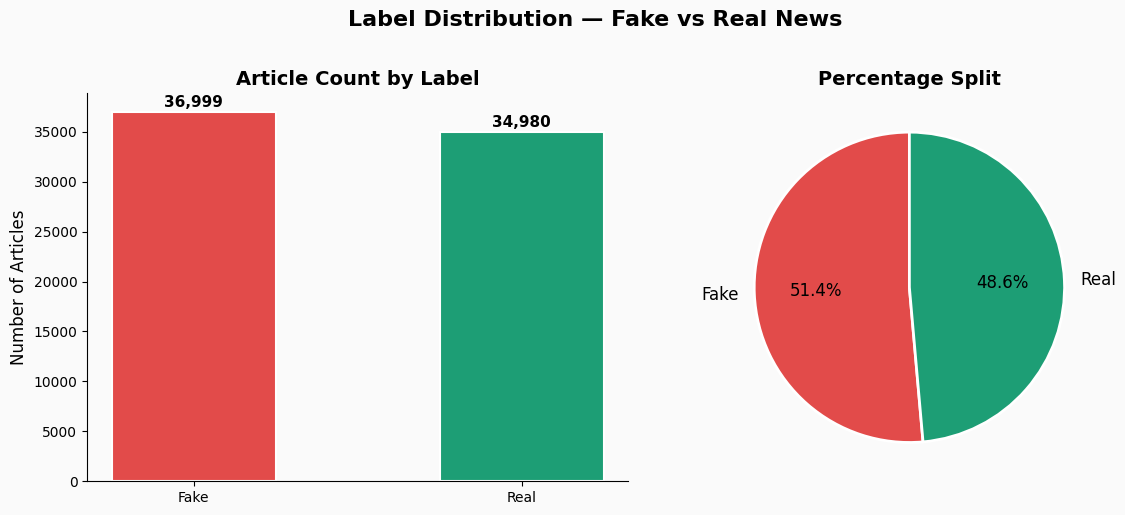

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Label Distribution — Fake vs Real News', fontsize=16, fontweight='bold', y=1.02)

counts = df['label_name'].value_counts()
colors = [FAKE_COLOR, REAL_COLOR]

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
axes[0].set_title('Article Count by Label')
axes[0].set_ylabel('Number of Articles')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Percentage Split')

plt.tight_layout()
plt.savefig("/content/drive/My Drive/Edunet_CLassification_Project/assets/01_label_distribution.png",
            dpi=150, bbox_inches="tight")

print("Plot saved to assets folder.")

## Step 6 — Visualization 2: Word Count Distribution

Avg word count — Fake: 501
Avg word count — Real: 579


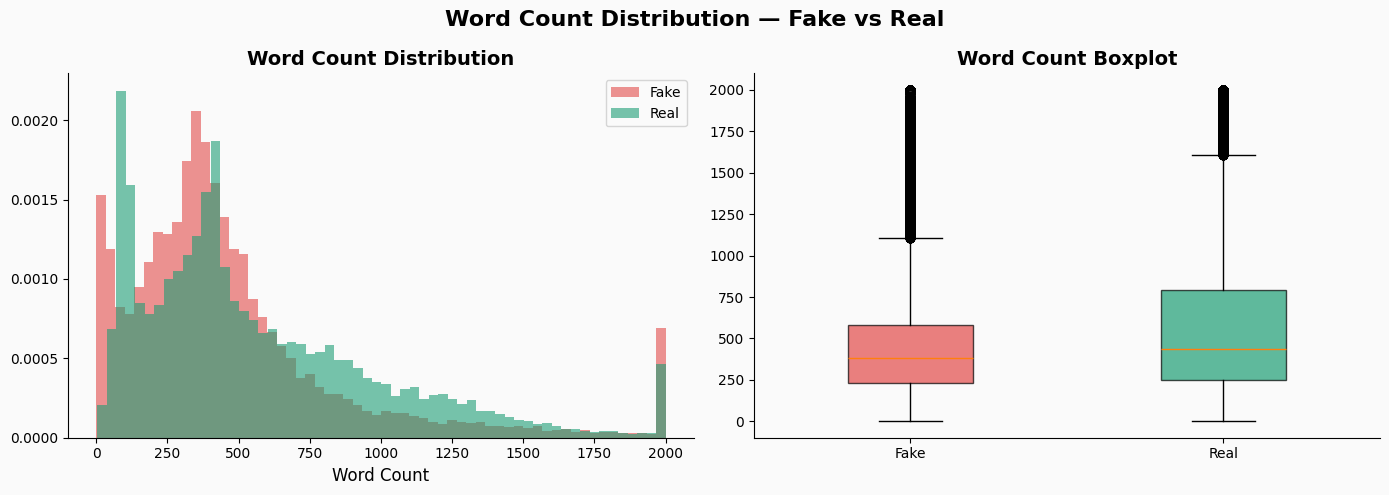

In [24]:
# ── Step 6: Visualization 2 — Word Count ─────────────────────────────
fake_df = df[df['label_name'] == 'Fake']
real_df = df[df['label_name'] == 'Real']
clip    = 2000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Word Count Distribution — Fake vs Real', fontsize=16, fontweight='bold')

axes[0].hist(fake_df['word_count'].clip(upper=clip), bins=60,
             alpha=0.6, color=FAKE_COLOR, label='Fake', density=True)
axes[0].hist(real_df['word_count'].clip(upper=clip), bins=60,
             alpha=0.6, color=REAL_COLOR, label='Real', density=True)
axes[0].set_title('Word Count Distribution')
axes[0].set_xlabel('Word Count')
axes[0].legend()

bp = axes[1].boxplot(
    [fake_df['word_count'].clip(upper=clip).values,
     real_df['word_count'].clip(upper=clip).values],
    patch_artist=True, labels=['Fake', 'Real'], widths=0.4)
bp['boxes'][0].set_facecolor(FAKE_COLOR); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(REAL_COLOR); bp['boxes'][1].set_alpha(0.7)
axes[1].set_title('Word Count Boxplot')

print(f"Avg word count — Fake: {fake_df['word_count'].mean():.0f}")
print(f"Avg word count — Real: {real_df['word_count'].mean():.0f}")

plt.tight_layout()
plt.savefig("/content/drive/My Drive/Edunet_CLassification_Project/assets/02_word_count.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 7 — Text Preprocessing Function

In [25]:
# ── Step 7: Text Cleaning Function ───────────────────────────────────
import re, nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

print("Cleaning text — takes 1-2 minutes...")
df['clean_text'] = df['content'].apply(clean_text)
print(f"Done. Sample: {df['clean_text'].iloc[0][:150]}")

Cleaning text — takes 1-2 minutes...
Done. Sample: law enforcement high alert following threats cops whites blacklivesmatter fyf terrorists video comment expected barack obama members fyf fukyoflag bla


## Step 8 — Visualization 3 & 4: Top 20 Words (Fake vs Real)

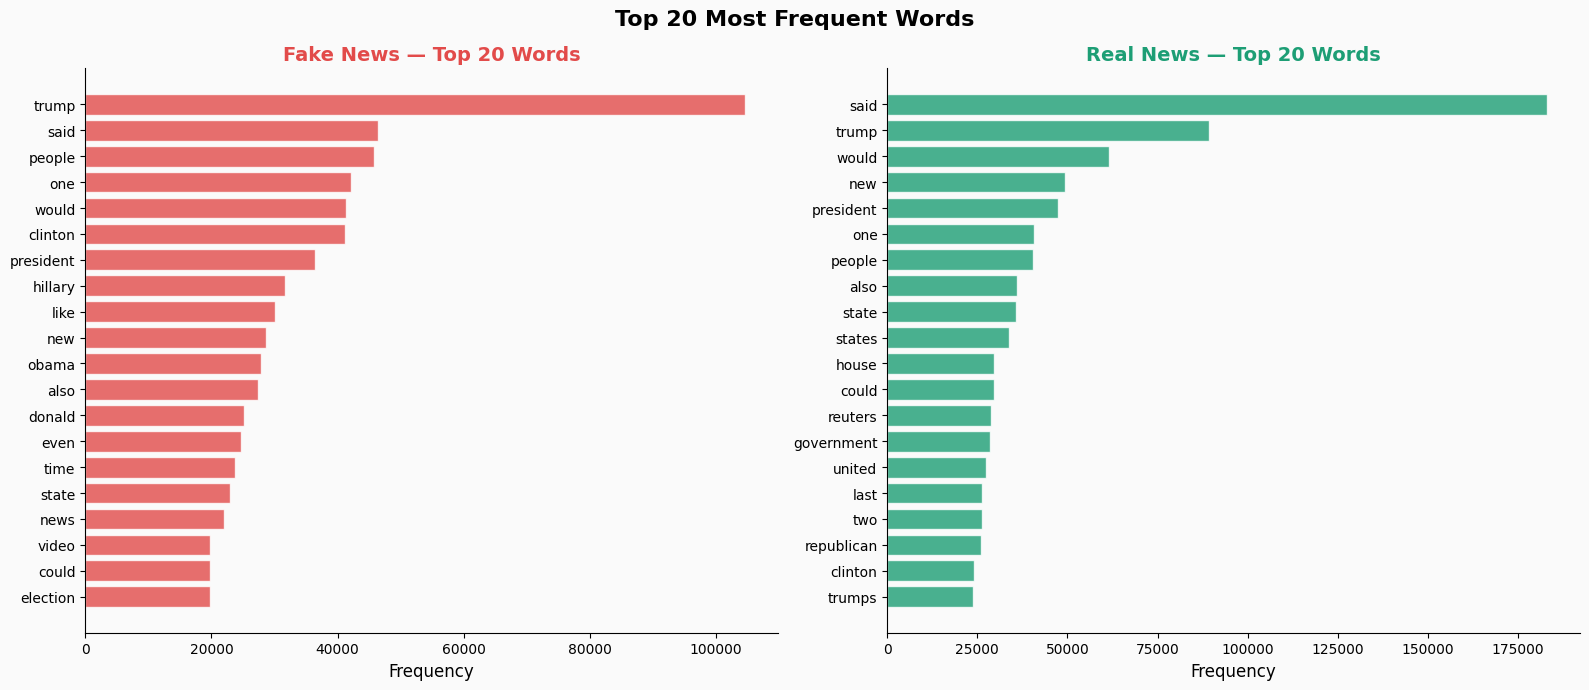


Notice: Are the top words different between Fake and Real?
This will tell you how discriminative word frequency is as a feature.


In [26]:
# ── Step 8: Visualization 3 — Top 20 Words ───────────────────────────
from collections import Counter

def get_top_words(series, n=20):
    all_words = ' '.join(series).split()
    return pd.DataFrame(Counter(all_words).most_common(n),
                        columns=['word', 'count'])

fake_words = get_top_words(df[df['label_name'] == 'Fake']['clean_text'])
real_words = get_top_words(df[df['label_name'] == 'Real']['clean_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Top 20 Most Frequent Words', fontsize=16, fontweight='bold')

for ax, words, color, title in [
    (axes[0], fake_words, FAKE_COLOR, 'Fake News'),
    (axes[1], real_words, REAL_COLOR, 'Real News')]:
    ax.barh(words['word'][::-1], words['count'][::-1],
            color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{title} — Top 20 Words', color=color)
    ax.set_xlabel('Frequency')
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Edunet_CLassification_Project/assets/03_top_words.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNotice: Are the top words different between Fake and Real?")
print("This will tell you how discriminative word frequency is as a feature.")

## Step 9 — Visualization 5 & 6: Word Clouds

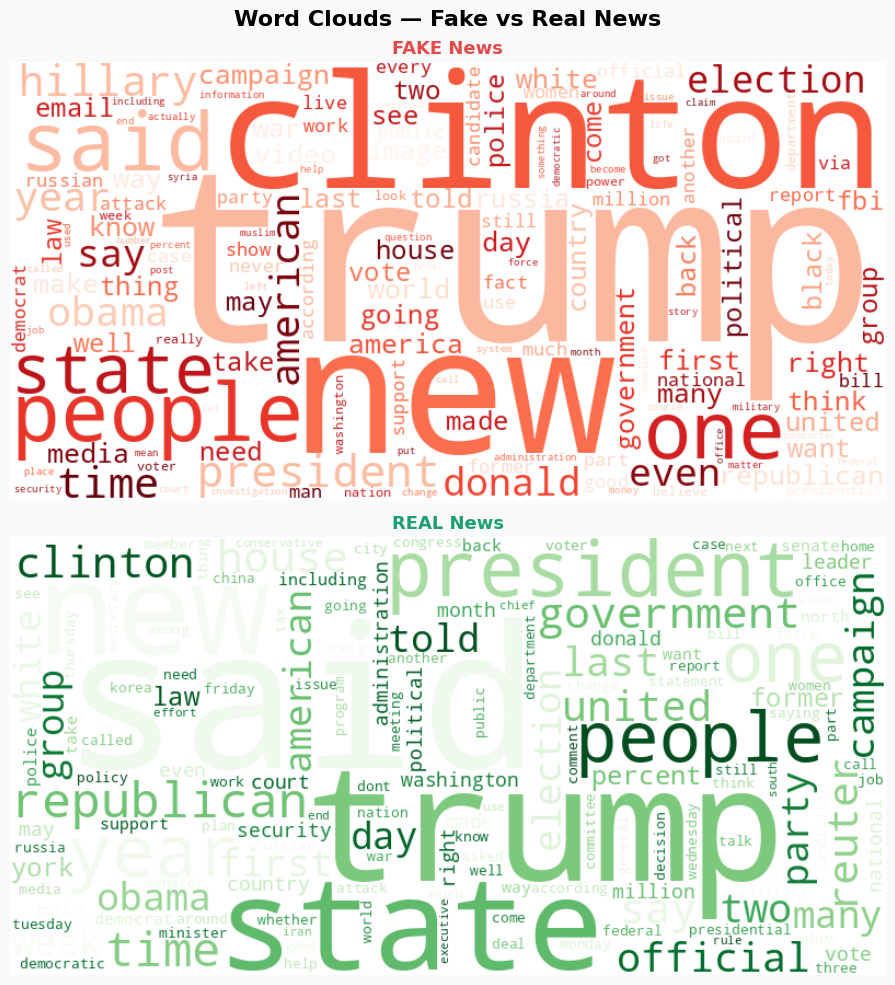

In [27]:
# ── Step 9: Visualization 4 — Word Clouds ────────────────────────────
from wordcloud import WordCloud, STOPWORDS

def make_wordcloud(series, colormap):
    return WordCloud(width=800, height=400, background_color='white',
                     colormap=colormap, max_words=150, stopwords=STOPWORDS,
                     collocations=False).generate(' '.join(series))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Word Clouds — Fake vs Real News', fontsize=16, fontweight='bold')

axes[0].imshow(make_wordcloud(df[df['label_name']=='Fake']['clean_text'], 'Reds'), interpolation='bilinear')
axes[0].set_title('FAKE News', color=FAKE_COLOR, fontsize=13); axes[0].axis('off')

axes[1].imshow(make_wordcloud(df[df['label_name']=='Real']['clean_text'], 'Greens'), interpolation='bilinear')
axes[1].set_title('REAL News', color=REAL_COLOR, fontsize=13); axes[1].axis('off')


plt.tight_layout()
plt.savefig('/content/drive/My Drive/Edunet_CLassification_Project/assets/04_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10 — Visualization 7: Sensationalism Features

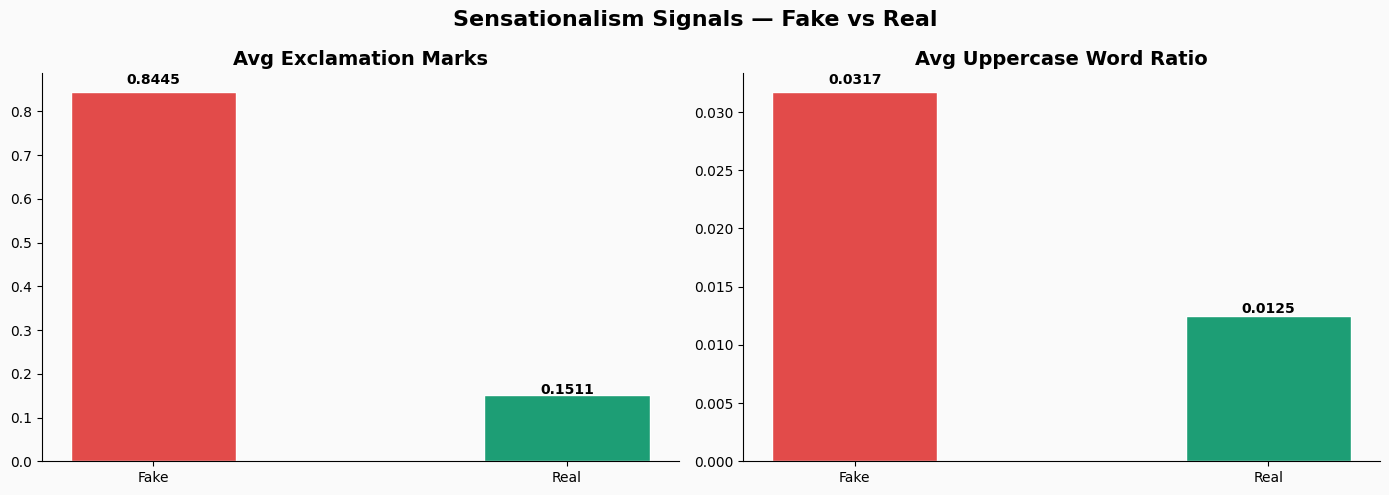


Key Insight: Do fake news articles use more exclamation marks or uppercase words?
This confirms whether sensationalism is a real signal in your dataset.


In [28]:
# ── Step 10: Visualization 5 — Sensationalism ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sensationalism Signals — Fake vs Real', fontsize=16, fontweight='bold')

for feature, ax, title in [
    ('exclamation_count', axes[0], 'Avg Exclamation Marks'),
    ('uppercase_ratio',   axes[1], 'Avg Uppercase Word Ratio')]:
    avg = df.groupby('label_name')[feature].mean()
    ax.bar(avg.index, avg.values,
           color=[FAKE_COLOR, REAL_COLOR], width=0.4, edgecolor='white')
    ax.set_title(title)
    for i, (label, val) in enumerate(avg.items()):
        ax.text(i, val + val*0.02, f'{val:.4f}', ha='center', fontweight='bold')


plt.tight_layout()
plt.savefig('/content/drive/My Drive/Edunet_CLassification_Project/assets/05_sensationalism.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Insight: Do fake news articles use more exclamation marks or uppercase words?")
print("This confirms whether sensationalism is a real signal in your dataset.")

## Step 11 — Save Cleaned Dataset for Notebook 2

In [29]:
# Save cleaned version for use in Model Training notebook
save_path = '/content/drive/My Drive/Edunet_CLassification_Project/data/WELFake_Cleaned.csv'
df[['content', 'clean_text', 'label', 'label_name',
    'word_count', 'char_count', 'exclamation_count',
    'uppercase_ratio']].to_csv(save_path, index=False)

# Final verification
df_verify = pd.read_csv(save_path)
print(f"Saved shape          : {df_verify.shape}")        # must be (N, 8)
print(f"Columns              : {df_verify.columns.tolist()}")
print(f"Null label_name      : {df_verify['label_name'].isnull().sum()}")  # must be 0
print(f"Label counts         :\n{df_verify['label_name'].value_counts()}")
print("\n✅ Notebook 1 complete — proceed to Notebook 3")

Saved shape          : (71979, 8)
Columns              : ['content', 'clean_text', 'label', 'label_name', 'word_count', 'char_count', 'exclamation_count', 'uppercase_ratio']
Null label_name      : 0
Label counts         :
label_name
Fake    36999
Real    34980
Name: count, dtype: int64

✅ Notebook 1 complete — proceed to Notebook 3


In [30]:
# Run in Notebook 1 after Step 11
import pandas as pd

df_check = pd.read_csv('/content/drive/My Drive/Edunet_CLassification_Project/data/WELFake_Cleaned.csv')

print("=== LABEL MAP VERIFICATION ===")
print(f"Shape: {df_check.shape}")
print(f"\nNull values in label_name: {df_check['label_name'].isnull().sum()}")
print(f"\nLabel distribution:")
print(df_check['label_name'].value_counts())
print(f"\nLabel numeric distribution:")
print(df_check['label'].value_counts())

print("\nSample — label=0 should be Real:")
print(df_check[df_check['label'] == 0][['label', 'label_name']].head(3))

print("\nSample — label=1 should be Fake:")
print(df_check[df_check['label'] == 1][['label', 'label_name']].head(3))

print("\nAssets saved:")
import os
assets = os.listdir('/content/drive/My Drive/Edunet_CLassification_Project/assets')
print(sorted(assets))

=== LABEL MAP VERIFICATION ===
Shape: (71979, 8)

Null values in label_name: 0

Label distribution:
label_name
Fake    36999
Real    34980
Name: count, dtype: int64

Label numeric distribution:
label
1    36999
0    34980
Name: count, dtype: int64

Sample — label=0 should be Real:
    label label_name
3       0       Real
11      0       Real
12      0       Real

Sample — label=1 should be Fake:
   label label_name
0      1       Fake
1      1       Fake
2      1       Fake

Assets saved:
['01_label_distribution.png', '02_word_count.png', '03_top_words.png', '04_wordclouds.png', '05_sensationalism.png']


## EDA Summary

| Observation | Finding |
|---|---|
| Dataset size | 72,134 articles |
| Label balance | ~50/50 split (check your chart) |
| Avg word count | Fake: ~X words, Real: ~X words |
| Top fake words | (fill after running) |
| Top real words | (fill after running) |
| Sensationalism | Fake articles have higher exclamation + uppercase ratio |

**Next step →** Notebook 2: Model Training